In [30]:
import numpy as np
import pandas as pd
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error,root_mean_squared_error,mean_absolute_percentage_error
from statsforecast import StatsForecast
import tqdm as notebook_tqdm

### Load data 

In [31]:
DATA_PATH_TRAIN=Path("data/train.csv")
DATA_PATH_VAL=Path("data/val.csv")
DATA_PATH_TEST=Path("data/test.csv")
train=pd.read_csv(DATA_PATH_TRAIN,index_col='Date', parse_dates=True)
val=pd.read_csv(DATA_PATH_VAL,index_col='Date', parse_dates=True)
test=pd.read_csv(DATA_PATH_TEST,index_col='Date', parse_dates=True)


In [32]:
train.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 913 entries, 2015-11-23 to 2019-05-22
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   High       913 non-null    float64
 1   Low        913 non-null    float64
 2   Open       913 non-null    float64
 3   Close      913 non-null    float64
 4   Volume     913 non-null    float64
 5   Adj Close  913 non-null    float64
dtypes: float64(6)
memory usage: 49.9 KB


### define target (y=close)

In [33]:
target='Close'

### Baseline models 

#### Naive (tomorrows prediction = todays value)

In [34]:
y_true = val[target]

In [35]:
y_pred = val[target].shift(1)
y_pred.iloc[0] = train[target].iloc[-1]

In [36]:
mae  = mean_absolute_error(y_true, y_pred)
rmse = root_mean_squared_error(y_true, y_pred)
mape = mean_absolute_percentage_error(y_true, y_pred)
print(f"Naive baseline | MAE: {mae:.2f} | RMSE: {rmse:.2f} | MAPE: {mape:.4%}")

Naive baseline | MAE: 16.36 | RMSE: 22.43 | MAPE: 0.5427%


In [37]:
results = {}
results['naive_val'] = {'MAE': mae, 'RMSE': rmse, 'MAPE': mape}

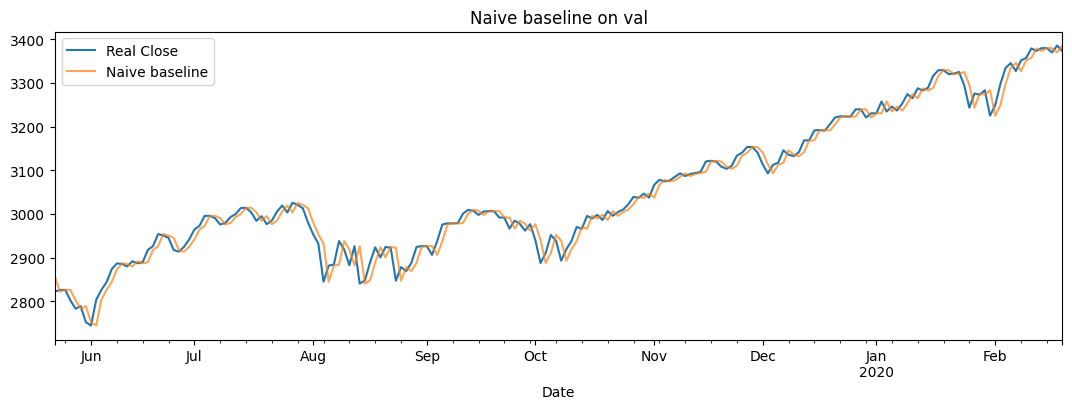

In [38]:
fig, ax = plt.subplots(figsize=(13,4))
y_true.plot(ax=ax, label='Real Close')
y_pred.plot(ax=ax, label='Naive baseline', alpha=0.7)
ax.set_title('Naive baseline on val')
ax.legend()
plt.show()

### Drift

In [39]:
y_true = val[target]+(val['Open']-val['Close'])

In [40]:
y_pred = val[target].shift(1)
y_pred.iloc[0] = train[target].iloc[-1]

In [41]:
mae  = mean_absolute_error(y_true, y_pred)
rmse = root_mean_squared_error(y_true, y_pred)
mape = mean_absolute_percentage_error(y_true, y_pred)
print(f"Naive baseline | MAE: {mae:.2f} | RMSE: {rmse:.2f} | MAPE: {mape:.4%}")

Naive baseline | MAE: 9.10 | RMSE: 11.91 | MAPE: 0.2998%


In [42]:
results = {}
results['naive_val'] = {'MAE': mae, 'RMSE': rmse, 'MAPE': mape}

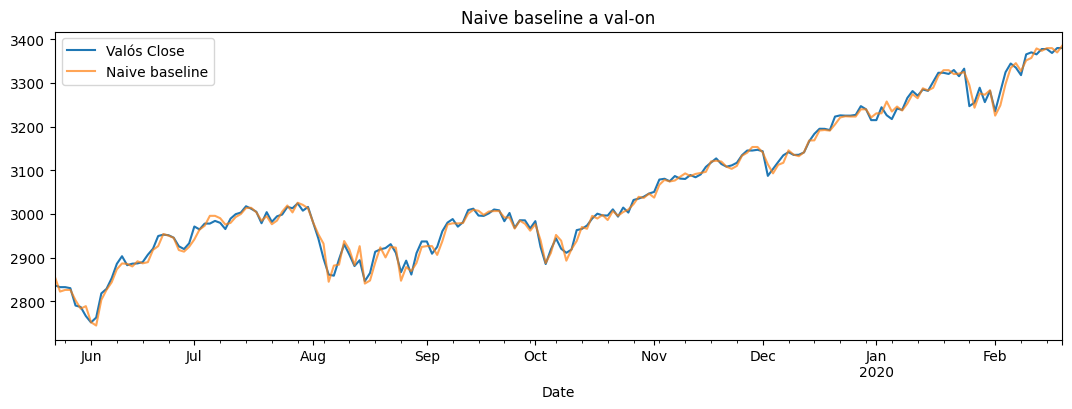

In [43]:
fig, ax = plt.subplots(figsize=(13,4))
y_true.plot(ax=ax, label='Valós Close')
y_pred.plot(ax=ax, label='Naive baseline', alpha=0.7)
ax.set_title('Naive baseline a val-on')
ax.legend()
plt.show()